2026-07-27 15:25:05.355 | INFO     | __main__:audit_node:38 - 任务阶段已经全部执行完毕,诗已生成,笑话已生成


{'topic': '猫咪', 'poem': AIMessage(content='## 《午后的猫》\n\n用粉红的肉垫踩踏光晕\n祖母绿的眼珠悬在虚空\n棉布沙发陷进慵懒弧度\n\n尾巴尖扫过茶杯沿壁\n留下半圈涟漪的印迹\n毛线球在木地板滚成某种禅意\n\n鱼骨状阴影爬上墙头\n时针开始缓慢反刍\n这个午后正以呼噜的形式\n\n被它吞咽\n又吐出\n一个毛茸茸的永恒', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 97, 'prompt_tokens': 10, 'total_tokens': 107, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 10}, 'model_provider': 'deepseek', 'model_name': 'deepseek-v4-flash', 'system_fingerprint': 'fp_8b330d02d0_prod0820_fp8_kvcache_20260402', 'id': 'be68a2c1-4239-4054-a3c2-ccf160da4947', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019fa276-819a-7043-93ea-4eef442e12e7-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 10, 'output_tokens': 97, 'total_tokens': 107, 'input_token_details': {'cache_read': 0}, 'output_token_details': {}}), 'joke': AIMessage(content='当然！这里有一个关于猫

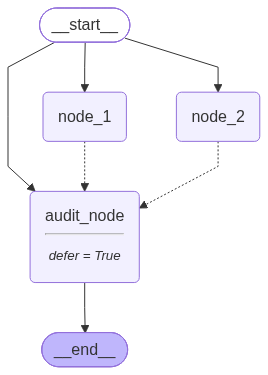

In [8]:
# -*- coding: utf-8 -*-
# 【CP2-05 延迟节点】defer=True 让审计/收尾节点等常规节点完成后才执行
# 文件：CP2/05_defer.ipynb
# 作用：本 Cell 演示 【CP2-05 延迟节点】defer=True 让审计/收尾节点等常规节点完成后才执行 的完整可运行示例
# 阅读顺序：状态定义 → 节点定义 → 图构建 → 编译执行 → 结果观察

from dotenv import load_dotenv
from langchain_deepseek import ChatDeepSeek
from langgraph.graph import StateGraph,START,END    
from typing import TypedDict, Annotated,Literal
from loguru import logger

load_dotenv()

model = ChatDeepSeek(
    model = "deepseek-v4-flash",
    extra_body={        
        "thinking":{
            "type":"disabled"
        }
    }
)

# 1 定义状态
class OverAllState(TypedDict):
    topic: str
    poem: str
    joke: str
    content_type: str

def node_1(state : OverAllState) -> OverAllState:
    # 向全局状态添加poem
    return {
        "poem": model.invoke(f"请写一首关于{state['topic']}的诗"),  # AND 汇合：需全部前驱完成才触发下游
    }

def node_2(state : OverAllState) -> OverAllState:
    # 向全局状态添加joke
    return {
        "joke": model.invoke(f"请写一个关于{state['topic']}的笑话"),  # AND 汇合：需全部前驱完成才触发下游
    }
# 定义延时节点
def audit_node(state: OverAllState) -> OverAllState:
    logger.info( f"任务阶段已经全部执行完毕,诗{'已生成' if state['poem'] else '未生成'},笑话{'已生成' if state['joke'] else '未生成'}" )  # AND 汇合：需全部前驱完成才触发下游

# 2 构建状态图
builder = StateGraph(state_schema=OverAllState)  # 创建状态图构建器：绑定状态 Schema
builder.add_node("node_1", node_1)  # 注册节点到图中
builder.add_node("node_2", node_2)  # 注册节点到图中
builder.add_node("audit_node", audit_node,defer=True)  # 注册延迟节点：等常规节点全部完成后才调度

builder.add_edge(START,"node_1")  # 起点扇出
builder.add_edge(START,"node_2")  # 起点扇出
builder.add_edge(START,"audit_node")  # 起点扇出

builder.add_edge("node_1", END)  # 汇入终点
builder.add_edge("node_2", END)  # 汇入终点
builder.add_edge("audit_node",END)  # 汇入终点

graph = builder.compile()  # 编译图：蓝图→可执行对象

result1 = graph.invoke({"topic": "猫咪"})  # 触发图执行：传入初始 State + config
print(result1)

from IPython.display import display
display(graph)
